# Analisi Salariale
**Obiettivo:** Analizzare il dataset dei salari per capire le relazioni tra le variabili e prevedere il salario usando modelli di regressione.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score


In [63]:
df = pd.read_csv("../data/raw/salary_prediction_data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


# Pulizia dei Dati

## Valori mancanti
Vediamo se ci sono valori nulli o assenti nel dataset.

In [64]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

Notiamo che ogni colonna ha 2 valori mancanti, quindi procediamo a risolvere questi problemi. Andiamo ad estrarre le righe del dataset corrispondenti ai valori mancanti

In [ ]:
df[df.isnull().any(axis=1)] # axis=1 scorre le righe e vede se in qualche colonna c'è un valore mancante

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
172,NaN,NaN,NaN,NaN,NaN,NaN
260,NaN,NaN,NaN,NaN,NaN,NaN


Notiamo che i valori mancanti corrispondono a due righe specifiche in cui non abbiamo informazioni, per cui eliminiamole dal nostro Dataset

In [68]:
# Metodo 1
# df = df.dropna()

# Metodo 2
df = df[~df.isnull().any(axis=1)]

Controlliamo ora se il nostro se ci sono ancora dei dati mancanti

In [69]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

A questo punto possiamo quindi salvare il nostro dataset pulito in un nuovo file csv

In [71]:
df.to_csv("C:/Users/mario/salary-prediction-analysis/data/processed/clean_df.csv", index=False)

# Analisi Esplorativa dei Dati (EDA)
In questa sezione esploreremo il dataset per capire la distribuzione delle variabili, la presenza di valori mancanti e le relazioni tra le feature e il salario.

In [73]:
df = pd.read_csv("C:/Users/mario/salary-prediction-analysis/data/processed/clean_df.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## Struttura del dataset
Verifichiamo il numero di righe, colonne e tipi di dati.

In [74]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.6 KB


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
count,373.000000,373,373,373,373.000000,373.000000
unique,NaN,2,3,174,NaN,NaN
top,NaN,Male,Bachelor's,Director of Marketing,NaN,NaN
freq,NaN,194,224,12,NaN,NaN
mean,37.431635,NaN,NaN,NaN,10.030831,100577.345845
std,7.069073,NaN,NaN,NaN,6.557007,48240.013482
min,23.000000,NaN,NaN,NaN,0.000000,350.000000
25%,31.000000,NaN,NaN,NaN,4.000000,55000.000000
50%,36.000000,NaN,NaN,NaN,9.000000,95000.000000
75%,44.000000,NaN,NaN,NaN,15.000000,140000.000000


## Distribuzione del salario
Analizziamo come sono distribuiti i salari nel dataset.

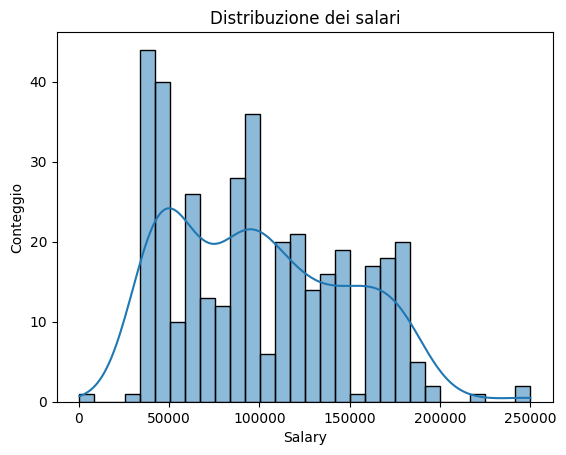

In [75]:
sns.histplot(df['Salary'], bins=30, kde=True)
plt.title("Distribuzione dei salari")
plt.xlabel("Salary")
plt.ylabel("Conteggio")
plt.show()

Notiamo che:
- La distribuzione dei salari non è simmetrica e ha più punti di massimo
- Questo suggerisce che è composta da più sottogruppi con distribuzioni diverse

## Correlazioni tra variabili numeriche
Controlliamo quali variabili numeriche sono più correlate con il salario usando la correlazione di Pearson.

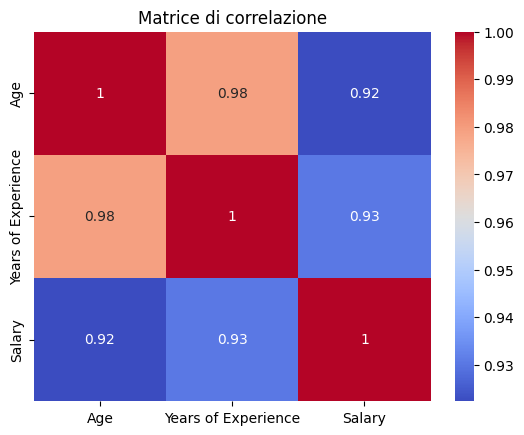

In [76]:
numeric_cols = df._get_numeric_data()
corr = numeric_cols.corr() # Ignora automaticamente i NaN
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matrice di correlazione")
plt.show()

Per avere certezze del coefficiente di correlazione di Pearson, andiamo a calcolare anche il **p-value**

#### "Age" - "Salary"

In [86]:
from scipy import stats
pearson_coef, p_value = stats.pearsonr(df["Age"], df["Salary"])
print("Pearson Correlation:", pearson_coef.round(2))
print("P-value:", p_value)

Pearson Correlation: 0.92
P-value: 2.7461207723240693e-155


#### "Years of Experience" - "Salary"

In [87]:
from scipy import stats
pearson_coef, p_value = stats.pearsonr(df["Years of Experience"], df["Salary"])
print("Pearson Correlation:", pearson_coef.round(2))
print("P-value:", p_value)

Pearson Correlation: 0.93
P-value: 1.0213700949589796e-163


Essendo il valore del **p-value** < 0.001, possiamo concludere che queste variabili sono molto correlate con il salario e la correlazione è positiva!

## Analisi delle variabili categoriche
Vediamo come le variabili categoriali (es. Education Level, Job Title, Gender) influenzano il salario.

#### "Education Level" - "Salary"

Education Level
Bachelor's    224
Master's       98
PhD            51
Name: count, dtype: int64


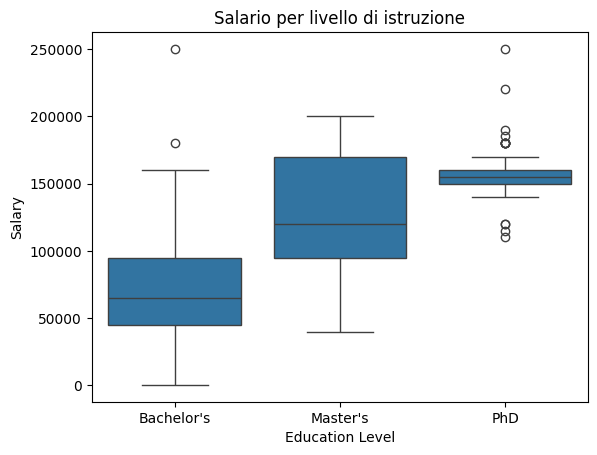

In [77]:
# Controllo frequenze
print(df['Education Level'].value_counts())

# Boxplot per capire la relazione con il salario
sns.boxplot(x='Education Level', y='Salary', data=df)
plt.title("Salario per livello di istruzione")
plt.show()

Vediamo che le due categorie Bachelor's e PhD hanno degli outliers, quindi individuiamoli utilizzando il **metodo IQR**.

In [78]:
# Lista per salvare gli outlier
outliers = pd.DataFrame()

# Itera su ogni livello di istruzione
for level in df['Education Level'].unique():
    salaries = df[df['Education Level'] == level]['Salary']
    Q1 = salaries.quantile(0.25)
    Q3 = salaries.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Seleziona gli outlier per questo livello
    outliers_level = df[(df['Education Level'] == level) & 
                        ((df['Salary'] < lower_bound) | (df['Salary'] > upper_bound))]
    
    outliers = pd.concat([outliers, outliers_level])

# Visualizza gli outlier trovati
print(outliers["Education Level"].value_counts(), "\n")
print(outliers)

Education Level
PhD           14
Bachelor's     2
Name: count, dtype: int64 

      Age  Gender Education Level                        Job Title  \
19   51.0    Male      Bachelor's                   Sales Director   
30   50.0    Male      Bachelor's                              CEO   
9    38.0    Male             PhD                 Senior Scientist   
17   39.0    Male             PhD                  Senior Engineer   
48   38.0    Male             PhD                 Senior Scientist   
63   47.0    Male             PhD            Senior Data Scientist   
72   45.0    Male             PhD                Research Director   
83   52.0    Male             PhD         Chief Technology Officer   
90   36.0    Male             PhD              Principal Scientist   
105  44.0    Male             PhD               Chief Data Officer   
158  51.0  Female             PhD      Director of Human Resources   
187  50.0  Female             PhD  Director of Sales and Marketing   
216  50.0  F

- Più alto il livello di istruzione, più alto tende a essere il salario mediano.
- La variabilità del salario è maggiore per i Master's e Bachelor's rispetto ai PhD.
- Ci sono outlier evidenti, soprattutto nei Bachelor's e PhD, quindi alcuni salari estremi influenzano la distribuzione.

--> Dunque l’**istruzione** è una variabile importante per predire il salario.

Calcoliamo per ogni "Educational level" la media, la mediana e la deviazione standard.

In [91]:
df_group = df[["Education Level", "Salary"]]
df_group = df_group.groupby(["Education Level"], as_index=False).agg(['mean','median','std'])
print(df_group)

  Education Level         Salary                        
                            mean    median           std
0      Bachelor's   74756.026786   65000.0  34777.272704
1        Master's  129795.918367  120000.0  41659.631919
2             PhD  157843.137255  155000.0  23393.479903


Da questa analisi vediamo che anche se la categoria dei PhD ha più outliers, in realtà **la media è circa uguale alla mediana** e la std è bassa, quindi quseto gruppo è stabile e abbastanza simmetrico, cioè i dati sono bilanciati.

Invece nel caso dei Master's abbiamo che la **media>mediana**, quindi ci sono pochi valori grandi che però influenzano molto la media. Inoltre la std è alta, quindi il gruppo è molto variabile e i dati sono dispersi. Per vederlo facciamo il grafico delle distribuzioni dei salari rispetto ai livelli di istruzione.

<function matplotlib.pyplot.show(close=None, block=None)>

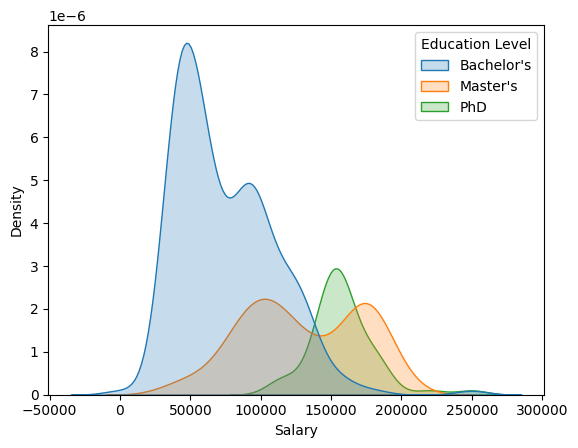

In [80]:
sns.kdeplot(data=df, x="Salary", hue="Education Level", fill=True)
plt.show

#### "Gender" - "Salary"

Gender
Male      194
Female    179
Name: count, dtype: int64


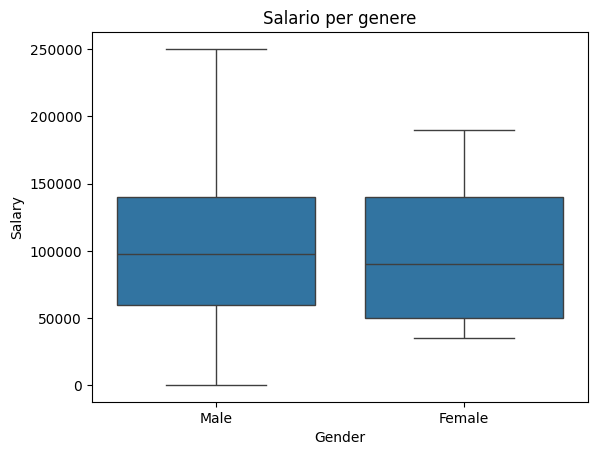

In [81]:
# Controllo frequenze
print(df['Gender'].value_counts())

# Boxplot per capire la relazione con il salario
sns.boxplot(x='Gender', y='Salary', data=df)
plt.title("Salario per genere")
plt.show()

Da questo grafico vediamo che:
- La mediana degli uomo è leggermente più alta rispetto alle donne
- Gli uomini mostrano valori massimi più elevati 
- Le distribuzion si sovrappongono molto, non c'è una separazione netta
--> non possiamo quindi dire che gli uomini guadagnano di più o se c'è un gender gap solo con questi dati, perché potrebbero esserci fattori nascosti come il ruolo, l'esprerienza...

In [82]:
#sns.boxplot(data=df, x="Education Level", y="Salary", hue="Gender")

#### "Job Title" - "Salary"
Infine andiamo a studiare la relazione tra "Job Title" e "Salary". Poiché abbiamo molti lavori diversi, andiamo innanzitutto a calcolare la **media per ogni titolo lavorativo**. Tuttavia poiché potrebbe capitare che ci sia una sola persona con un certo lavoro, per studiare la media, andiamo a considerare i casi in cui ci sono almeno 5 persone con lo stesso titolo.

In [83]:
counts = df["Job Title"].value_counts()
valid_jobs = counts[counts >= 5].index

df_filtrato = df[df["Job Title"].isin(valid_jobs)]

df_filtrato.groupby("Job Title")["Salary"].mean().sort_values(ascending=False)

Job Title
Director of Marketing                    175833.333333
Director of Operations                   172727.272727
Senior Data Scientist                    160000.000000
Senior Product Designer                  148000.000000
Senior Project Manager                   129285.714286
Senior Marketing Manager                 127222.222222
Senior Product Manager                   121666.666667
Senior Software Engineer                 120833.333333
Senior Business Analyst                  116000.000000
Senior Financial Analyst                 112857.142857
Senior Operations Manager                108000.000000
Senior Financial Manager                 100000.000000
Senior Project Coordinator                92000.000000
Senior Marketing Analyst                  89444.444444
Junior Marketing Specialist               53000.000000
Junior Financial Analyst                  52857.142857
Junior Operations Analyst                 51000.000000
Junior Business Analyst                   50000.000000


Quello che possiamo affermare è che i salari aumentano con la seniority implicita nel job title

## Sviluppo del modello

#### Preparazione dei dati
La nostra variabile target è il "Salary", mentre come variabili predictor andiamo a considerare "Age", "Years of Experience" e l'"Education Level"

In [110]:
df_encoded = pd.get_dummies(df, columns=["Gender", "Education Level"], drop_first=True)

X = df_encoded.drop(["Salary","Job Title"], axis=1)
Y = df["Salary"]

# Separiamo le variabili di training da quelle di test (80% training data - 20% test data)
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2)

#### Modello di Regressione Lineare Multipla
Andiamo ad addestrare un modello di regressione lineare multipla (le variabili devono essere indipendenti)
 $$\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + b_3 x_3 + \ldots $$

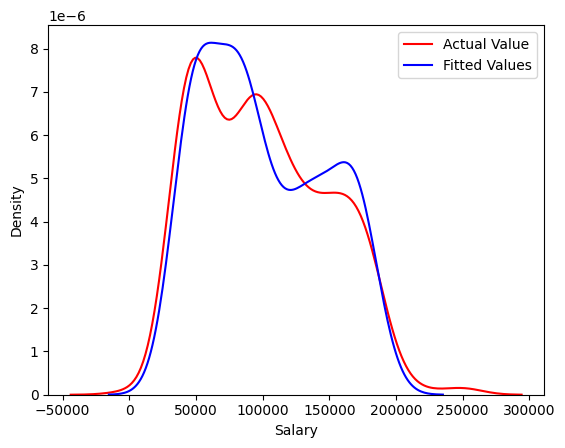

In [119]:
model = LinearRegression()
model.fit(x_train, y_train)
Yhat = model.predict(x_train)

ax_1 = sns.kdeplot(data=df["Salary"], color="r", label="Actual Value")
sns.kdeplot(data=Yhat, color="b", label="Fitted Values", ax=ax_1)
plt.legend()

## Validazione del modello
Calcoliamo l'$R^2$

In [117]:
r2_train = model.score(x_train,y_train)
print("L'R^2 dei training test è:", r2_train, "\n")

r2_test = model.score(x_test, y_test)
print("L'R^2 dei data test è:", r2_test)

L'R^2 dei training test è: 0.9038411584063146 

L'R^2 dei data test è: 0.8725617503209822


Text(0.5, 1.0, 'Valori reali vs valori predetti del salario')

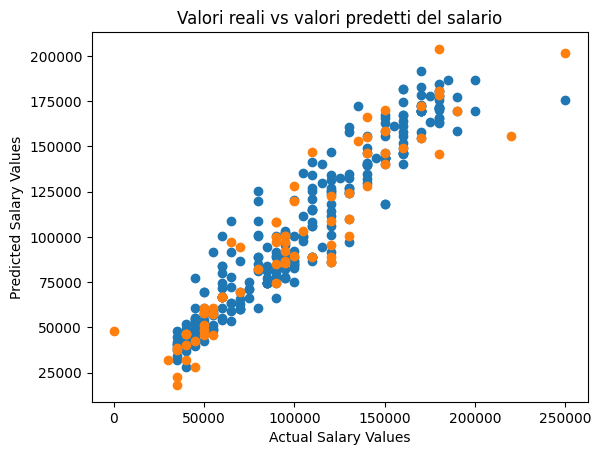

In [ ]:
y_pred_train = model.predict(x_train)
plt.scatter(y_train, y_pred_train)

y_pred_test = model.predict(x_test)
plt.scatter(y_test, y_pred_test)

plt.xlabel("Actual Salary Values")
plt.ylabel("Predicted Salary Values")
plt.title("Actual vs Predicted Salary (Train vs Test)")

Text(0, 0.5, 'Residuals')

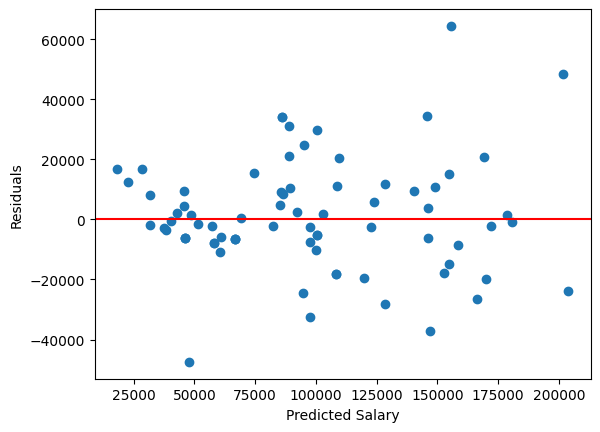

In [127]:
residuals = y_test - y_pred_test

plt.scatter(y_pred_test, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")

I punti sono
- centrati intorno a 0
- abbastanza sparsi
--> quindi il modello non ha un bias evidente (non sovrastima sempre o sottostima sempre)

Notiamo però che per salari bassi abbiamo errori più piccoli e punti abbastanza vicini allo 0, mentre per salari alti l'errore è più grande e la dispersione aumenta. Questo fenomeno è detto **ETEROSCHEDASTICITÀ**

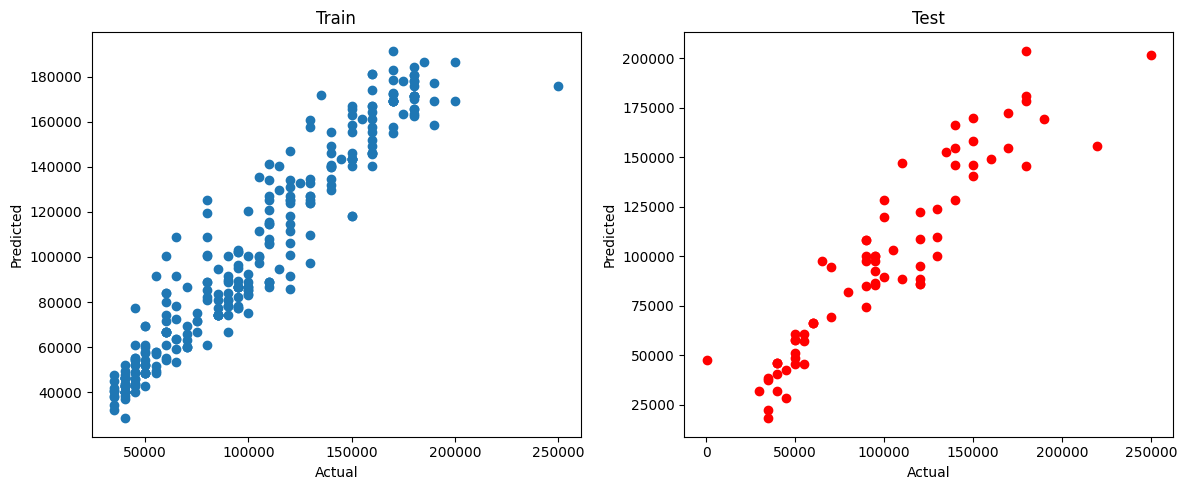

In [130]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Primo grafico
axes[0].scatter(y_train, y_pred_train)
axes[0].set_title("Train")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# Secondo grafico
axes[1].scatter(y_test, y_pred_test, color="r")
axes[1].set_title("Test")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

#### Conclusioni
- Il modello ha buona capacità predittiva (R² ~0.87 sul test)
- Non si osserva overfitting evidente (train ≈ test)
- L’errore aumenta per salari elevati